## Business Problem

In the USA the leading cause of death and most exoensive disease to treat is heart disease. Considering mentioned statistics, this pipeline aims to assist professionals to identify patients with high risk of heart disease sooner, and as a consequence, improve treatment plans and prevant sever outcome such as heart attack and hospitalization for them.

## Why is it important

Executing a new rule for hospitals and clinics to use this pipeline helps doctors to identify high-risk patients faster. This is important because doctors can run further medical examination and advice preventive actions and lifestyle counselling to mitigate the risk of disastrous outcome. Therefore, his preventive rule create both medical and economical benefits.

## How the organization benefits

By utilising a trustworthy predictive model, the organization can detect risk patterns accross different groups, increase healthcare efficiency, and support the process of decision making for public health.

## Data Collection

The presented machine learning system is designed for the Department of Health & Service of the USA. Originally the dataset is driven from CDC and is a major part of the Behavioral Risk Factor Surveillance System (BRFSS). However, from 300 features, only 40 of them that are most relevant to heart disease was chosen for this dataset [1]. The dataset includes both categorical and numerical data types regarding health status of more than 445,000 citizen in the USA. The data include health factors such as several diseases and difficulties, lifestyle factors, and few personal information such the state each participant lives in or their sex and age category.

## Machine learning formulation

The problem can be formulated as a supervised binary classification task in which all the features of the dataset are considerate as input except for the target feature, HadHeartAttack, that has two classes: 'Yes' and 'No'.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import time

import sklearn.preprocessing
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

import tensorflow as tf

In [3]:
heartAttack_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Datasets/heart_2022_with_nans.csv')

# Data Preprocessing and Exploration

The dataset contains several missing values arcoss the columns, however, since the dataset is quite massive, even after removing all rows with missing values we are still left with a great number of data. Therefore all the rows with missing values were removed.

Next code cell checks the balance of classes in target feature to make sure the training will not be biased. Otherwise the model learns one class of the target column very well while not knowing much about the other class.

Since the classes in the targer column is highly imbalanced, the dataset is first seperated by the classes and then 1500 rows of each class is randomly chosen and stored, after that the 3000 rows from two classes are combined and shuffeled. If not shuffeled then the model will be trained solely on 'Yes' class and 30% of the 'No' class, and then will be tested on the remaining 20% of the 'No' class.

After that a small part of dataset, its statistics and histograms of the numerical columns is shown for inspection.

Finally, the dataset is split into train (80%) and test (20%) set and the target column is stripped from both sets to prevant data leakage.

In [4]:
heart_nonull = heartAttack_df.dropna()
heart_nonull.shape

(246022, 40)

In [5]:
print(heart_nonull['HadHeartAttack'].value_counts())
print(heart_nonull['HadHeartAttack'].value_counts(normalize=True))

HadHeartAttack
No     232587
Yes     13435
Name: count, dtype: int64
HadHeartAttack
No     0.945391
Yes    0.054609
Name: proportion, dtype: float64


In [6]:
target_col = 'HadHeartAttack'

yes_rows = heart_nonull[heart_nonull[target_col] == 'Yes']
no_rows  = heart_nonull[heart_nonull[target_col] == 'No']

sampled_yes = yes_rows.sample(n=1500, random_state=42)
sampled_no = no_rows.sample(n=1500, random_state=42)

heart_sample = pd.concat([sampled_yes, sampled_no], axis=0)

heart_sample = heart_sample.sample(frac=1, random_state=42).reset_index(drop=True)

print(heart_sample.shape)
print(heart_sample['HadHeartAttack'].value_counts())

(3000, 40)
HadHeartAttack
No     1500
Yes    1500
Name: count, dtype: int64


In [8]:
heart_sample.head(5)

,State,Sex,GeneralHealth,PhysicalHealthDays,MentalHealthDays,LastCheckupTime,PhysicalActivities,SleepHours,RemovedTeeth,HadHeartAttack,...,HeightInMeters,WeightInKilograms,BMI,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
0,Texas,Male,Very good,0.0,0.0,Within past 5 years (2 years but less than 5 y...,No,8.0,None of them,No,...,1.80,86.18,26.50,Yes,No,Yes,No,"Yes, received tetanus shot, but not Tdap",No,No
1,District of Columbia,Female,Poor,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,16.0,"6 or more, but not all",Yes,...,1.70,78.47,27.10,No,Yes,Yes,Yes,"Yes, received Tdap",No,No
2,New Jersey,Female,Very good,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,5.0,None of them,No,...,1.63,72.57,27.46,Yes,No,Yes,Yes,"Yes, received Tdap",No,Yes
3,Texas,Female,Fair,30.0,7.0,Within past year (anytime less than 12 months ...,No,8.0,1 to 5,Yes,...,1.65,90.72,33.28,Yes,Yes,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,No
4,Louisiana,Male,Fair,3.0,0.0,Within past 2 years (1 year but less than 2 ye...,Yes,7.0,1 to 5,No,...,1.75,102.51,33.37,No,No,Yes,Yes,"Yes, received Tdap",No,Yes


In [9]:
print(heart_sample.describe())

       PhysicalHealthDays  MentalHealthDays   SleepHours  HeightInMeters  \
count         3000.000000       3000.000000  3000.000000     3000.000000   
mean             6.318667          4.675667     6.988333        1.708607   
std             10.314484          8.889215     1.606152        0.107284   
min              0.000000          0.000000     1.000000        1.320000   
25%              0.000000          0.000000     6.000000        1.630000   
50%              0.000000          0.000000     7.000000        1.700000   
75%              7.000000          5.000000     8.000000        1.780000   
max             30.000000         30.000000    18.000000        2.080000   

       WeightInKilograms          BMI  
count        3000.000000  3000.000000  
mean           85.369370    29.145973  
std            21.265284     6.417926  
min            36.290000    12.340000  
25%            70.310000    24.827500  
50%            81.650000    28.130000  
75%            97.520000    32.2800

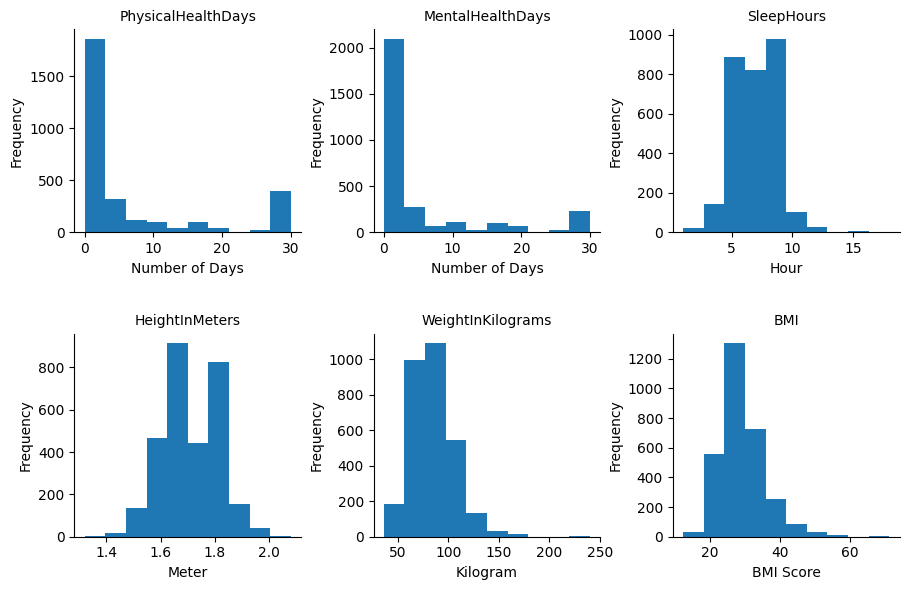

In [11]:
numerical_columns = heart_sample.select_dtypes(include=['int64', 'float64'])
melted = pd.melt(numerical_columns)

g = sns.FacetGrid(melted, col="variable", col_wrap=3, sharex=False, sharey=False)
g.map(plt.hist, "value")
g.set_titles("{col_name}")
x_labels = ["Number of Days", "Number of Days", "Hour", "Meter", "Kilogram", "BMI Score"]
for ax, xlabel in zip(g.axes.flat, x_labels):
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Frequency")
plt.subplots_adjust(hspace=0.5)

plt.show()

In [12]:
heartAttack_train, heartAttack_test = sklearn.model_selection.train_test_split(heart_sample, test_size=0.2)

print("Dataset shape: ", heart_sample.shape)
print("Train set shape: ", heartAttack_train.shape)
print("Test set shape: ", heartAttack_test.shape)

Dataset shape:  (3000, 40)
Train set shape:  (2400, 40)
Test set shape:  (600, 40)


In [13]:
x_train = heartAttack_train.drop("HadHeartAttack", axis=1)
y_train = heartAttack_train['HadHeartAttack']

x_test = heartAttack_test.drop("HadHeartAttack", axis=1)
y_test = heartAttack_test['HadHeartAttack']

print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(2400, 39)
(2400,)
(600, 39)
(600,)


# Feature Engineering

The purpose of feature engineering is to convert data into a form that the model can learn from them effectively. Since most machine learning models cannot work directly with strings, One Hot Encoder was adopted to convert categories into numerical indicator columns. Likewise, Standard Scaler was adopted to scale the numerical features (with a mean of ≈ 0, and standard deviation of ≈ 1) so that the model can have a more stable training and more balanced coefficients.

In [14]:
numerical_attr = x_train.select_dtypes(include=['int64', 'float64']).columns
categorical_attr = x_train.select_dtypes(include=['object']).columns

ct = sklearn.compose.ColumnTransformer(
    [
        ('standard_scaler', sklearn.preprocessing.StandardScaler(), numerical_attr),
        ('one_hot_encoder', sklearn.preprocessing.OneHotEncoder(), categorical_attr)
    ]
)

ct.fit(x_train)

x_train = ct.transform(x_train)
x_test = ct.transform(x_test)

print(x_train.shape)
print(x_test.shape)

(2400, 154)
(600, 154)


In [15]:
y_train = y_train.map({'No': 0, 'Yes': 1})
y_test = y_test.map({'No': 0, 'Yes': 1})

# Model Training

It creates a three-layer neural network with an input shape of 154 in the input layer, two neuron and a Sigmoid activation function for the second layer and finally one neuron in the output layer (there is one neuron in the output layer since it's a binary classification task and the output of this model is wither yes or no).

Later it fine-tunes hyperparameters of the model with parameters such as optimizer, learning rate, loss function and evaluation metrics. Since the classes in target are balanced, Accuracy metric is a correct evaluation method.

Finally it trains the model with a validation set that is 20% of the train set and an epochs of 100. The training time is also recorded using time.perf_counter function (for timing model training it is recomended to use time.perf_counter() rather than time.time()).

In [16]:
model = tf.keras.Sequential([
     tf.keras.layers.Flatten(input_shape=(154,)),
     tf.keras.layers.Dense(2, activation='sigmoid'),
     tf.keras.layers.Dense(1)
 ])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [17]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [18]:
start_time = time.perf_counter()

model.fit(x_train, y_train, validation_split=0.20, epochs=100)

end_time = time.perf_counter()
elapsed_time = end_time - start_time
print(f"Fitting took {elapsed_time:.4f} seconds")

Epoch 1/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6198 - loss: 0.6554 - val_accuracy: 0.6750 - val_loss: 0.6214
Epoch 2/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7141 - loss: 0.5953 - val_accuracy: 0.6917 - val_loss: 0.5791
Epoch 3/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7417 - loss: 0.5534 - val_accuracy: 0.7208 - val_loss: 0.5446
Epoch 4/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7552 - loss: 0.5208 - val_accuracy: 0.7396 - val_loss: 0.5197
Epoch 5/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7677 - loss: 0.4976 - val_accuracy: 0.7563 - val_loss: 0.5021
Epoch 6/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7719 - loss: 0.4803 - val_accuracy: 0.7604 - val_loss: 0.4909
Epoch 7/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7792 - loss: 0.4680 - val_accuracy: 0.7667 - val_loss: 0.4835
Epoch 8/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7859 - loss: 0.4589 - val_accuracy: 0.7750 - v

# Experimental Section

The rows with a star in the beginning indicate that their validation accuracy score is the average score of five times running since the scores of those rows are similar to one another.

The best model has 3 layers (input, hidden, and output layer) with two neurons in the hidden layer and one neuron in the output layer. It adopts Adam optimizer with a learning rate of 0.001, binary_crossentropy loss function and Accuracy as evaluation metric.

On the best model, exactly one change at a time was made to determine the effect of each change. There are a total of ten experiments which is shown in the table below with their Validation accuracy acore and Fitting time in second.

NO  | Experiment         | Fitting Duration (second) | Validation Accuracy
----|--------------------|---------------------------|--------------------
0   |* The Best Model | 24.54 | 0.80
1   |Learning Rate = 0.01|  45.61 | 0.48
2   |Learning Rate = 0.0001|  43.80 | 0.60
3   |First Layer = 10 Neurons|  44.15 | 0.51
4   |4-Layer, Second Layer = 10 Neurons| 49.03 | 0.51
5   |* With Batch Normalization = 64| 33.84 | 0.78
6   |Optimizer = SGD|  39.56 | 0.47
7   |* With Batch Normalization = 32| 30.25 | 0.76
8   |Optimizer = Adagrad| 46.27 | 0.50
9   |Optimizer = Adadelta| 41.98 | 0.48
10  |4-Layer, Second Layer = 4 Neurons| 42.51| 0.49 |

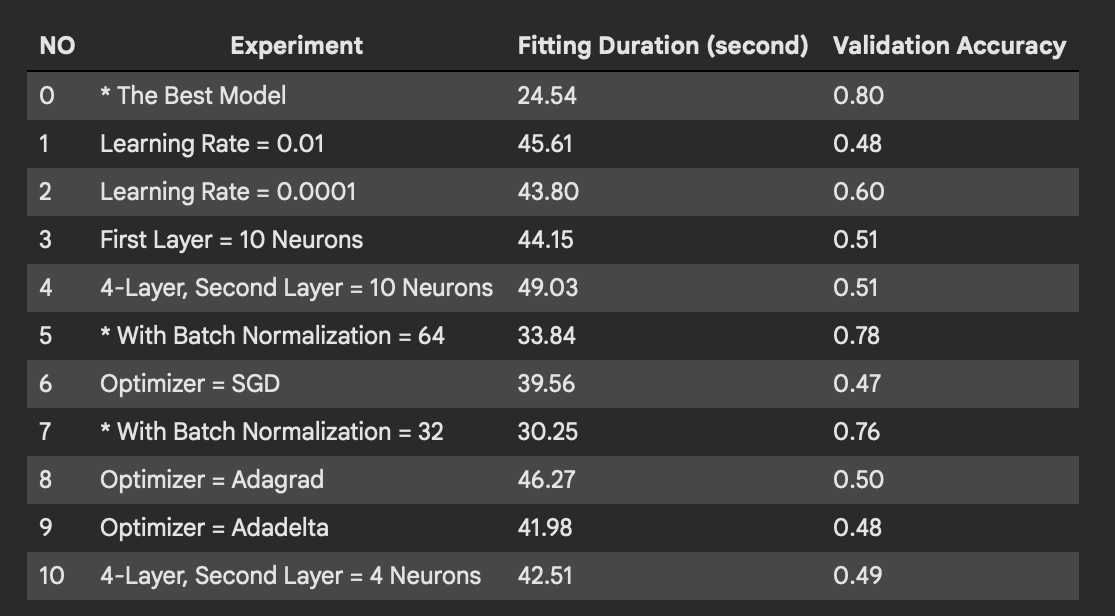

# Model Testing

In [19]:
test_loss, test_acc = model.evaluate(x_test,  y_test, verbose=2)

print('\nTest accuracy:', test_acc)

19/19 - 0s - 9ms/step - accuracy: 0.7783 - loss: 0.6041

Test accuracy: 0.778333306312561


# Final Discussion

* **Strength**: The proposed pipeline solves an important public health problem. The dataset contains large real-world data which gives the model a strong foundation. The dataset was cleaned and target classes were checked and treated for imbalances. Numerical and categorical features were correctly standardized and encoded. Multiple neural network configurations were tested by changing one factor at a time, which makes the design process structured and justified. Good validation accuracy of 0.80 for the best model.

* **Limitation**: Comparing to other machine learning models such as Logistic Regression or Decision Tree, it is harder to explain exactly how a neural nerwork reaches a prediction, which makes it less transparent and limits the interpretability.

* **Implication**: The results offer practical value but it must not be used as a standalone diagnostic tool. Hospitals and clinics can use it to flag patients for further examination, early identification can support preventive interventions which both helps the patients to mitigate the risk of disastrous health outcome as well as reducing the costs assosiated with severe cardic events.

* **Data-Driven Recommendation**: The pipeline must be used as a risk stratification tool to detect high-risk individuals, and must not be considered as a replace for physicians.

* **Explainability**: At a high-level, the pipeline is explainable, however, since the final predictive model is a neural network, it is hard to identify how each input feature contribuse to each prediction.

* **Deployment Decision**: The model can be deployed as a decision-support or screening assistance tool, however, it is important for the machine learning models to be retrained on the original dataset, and reviewed by domain experts. With respect to the current performance, it is adviced to remain a prototype for analysis, rather than immediate deployment.

Dataset: https://www.kaggle.com/datasets/kamilpytlak/personal-key-indicators-of-heart-disease$0